阶段1输出： ['自', '然', '语', '言', '处', '理', '是', '人', '工', '智', '能', '的', '重', '要', '领', '域', '之', '一', ',', '但', '是', '处', '理', '自', '然', '语', '言', '需', '要', '先', '把', '自', '然', '语', '言', '转', '换', '成', '模', '型', '可', '以', '理', '解', '的', '向', '量'] Length: 47
Token indices: [2, 3, 4, 5, 7, 6, 8, 11, 12, 13, 14, 9, 15, 10, 16, 17, 18, 19, 20, 21, 8, 7, 6, 2, 3, 4, 5, 22, 10, 23, 24, 2, 3, 4, 5, 25, 26, 27, 28, 29, 30, 31, 6, 32, 9, 33, 34]


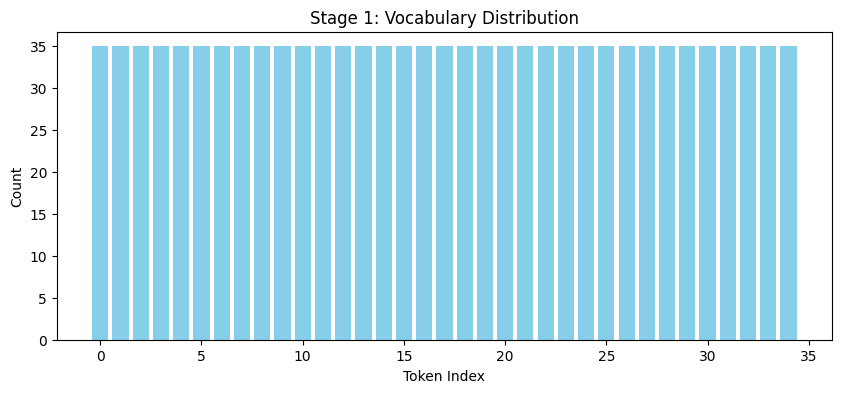

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import Counter

# 输入句子
sentence = "自然语言处理是人工智能的重要领域之一,但是处理自然语言需要先把自然语言转换成模型可以理解的向量"  # 20字左右的中文句子

""" 阶段1：文本预处理和词汇表构建 """
# 分词处理
tokens = list(sentence)  # 中文按字符分词
print("阶段1输出：", tokens, "Length:", len(tokens))

# 构建词汇表
vocab = {'<pad>': 0, '<unk>': 1}
for token, _ in Counter(tokens).most_common():
    vocab[token] = len(vocab)
reverse_vocab = {v: k for k, v in vocab.items()}

# 转换为索引序列
token_indices = [vocab.get(token, vocab['<unk>']) for token in tokens]
print("Token indices:", token_indices)

# 可视化词汇表分布
plt.figure(figsize=(10, 4))
plt.bar(range(len(vocab)), [len(vocab)]*len(vocab), color='skyblue')
plt.title("Stage 1: Vocabulary Distribution")
plt.xlabel("Token Index")
plt.ylabel("Count")
plt.show()



阶段2输出形状： torch.Size([47, 128])


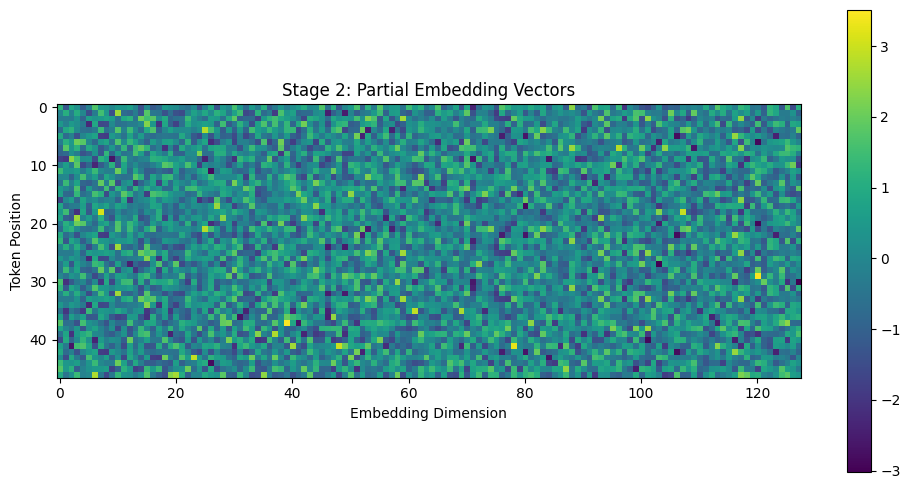

In [2]:
""" 阶段2：Embedding层 """
embedding_dim = 128
embedding = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embedding_dim)
embedded = embedding(torch.LongTensor(token_indices))
print("\n阶段2输出形状：", embedded.shape)

# 可视化部分词嵌入
plt.figure(figsize=(12, 6))
plt.imshow(embedded.detach().numpy()[:, :], cmap='viridis')  # 显示前10维
plt.colorbar()
plt.title("Stage 2: Partial Embedding Vectors")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.show()


阶段3输出形状： torch.Size([47, 128])


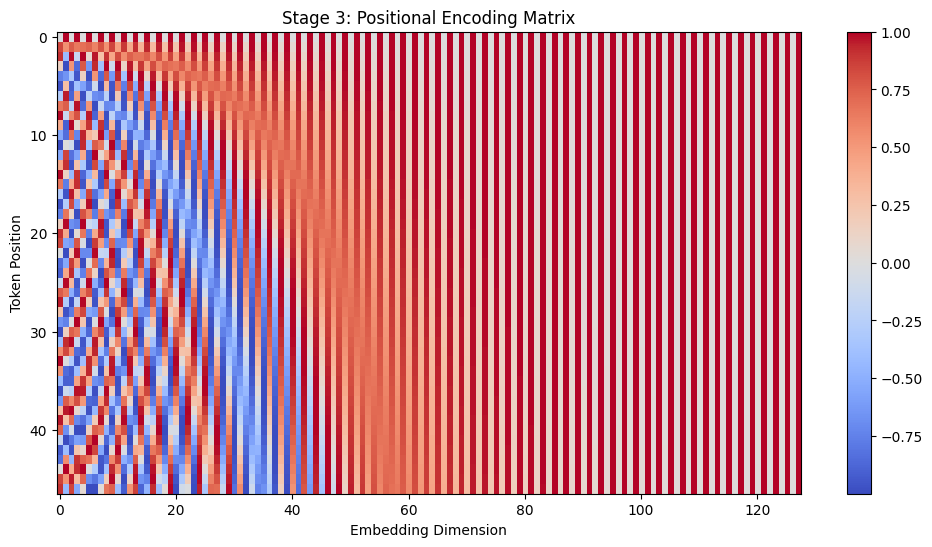

In [3]:
""" 阶段3：Position Encoding """
max_len = len(tokens)  # 输入序列长度
d_model = embedding_dim

def positional_encoding(max_len, d_model):
    position = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
    
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return torch.FloatTensor(pe)

pos_encoding = positional_encoding(max_len, d_model)
print("\n阶段3输出形状：", pos_encoding.shape)

# 可视化位置编码
plt.figure(figsize=(12, 6))
plt.imshow(pos_encoding.numpy(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Stage 3: Positional Encoding Matrix")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.show()


阶段4输出形状： torch.Size([47, 128])


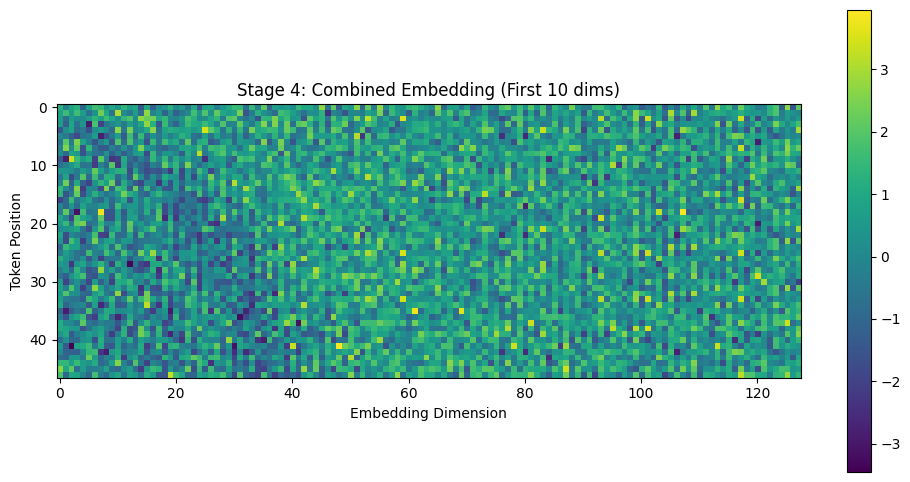

In [6]:
""" 阶段4：Embedding + Position Encoding """
final_embedding = embedded + pos_encoding
print("\n阶段4输出形状：", final_embedding.shape)

# 可视化最终结果
plt.figure(figsize=(12, 6))
plt.imshow(final_embedding.detach().numpy()[:, :], cmap='viridis')
plt.colorbar()
plt.title("Stage 4: Combined Embedding (First 10 dims)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")
plt.show()

[[ 0]
 [ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]
 [21]
 [22]
 [23]
 [24]
 [25]
 [26]
 [27]
 [28]
 [29]
 [30]
 [31]
 [32]
 [33]
 [34]
 [35]
 [36]
 [37]
 [38]
 [39]
 [40]
 [41]
 [42]
 [43]
 [44]
 [45]
 [46]]


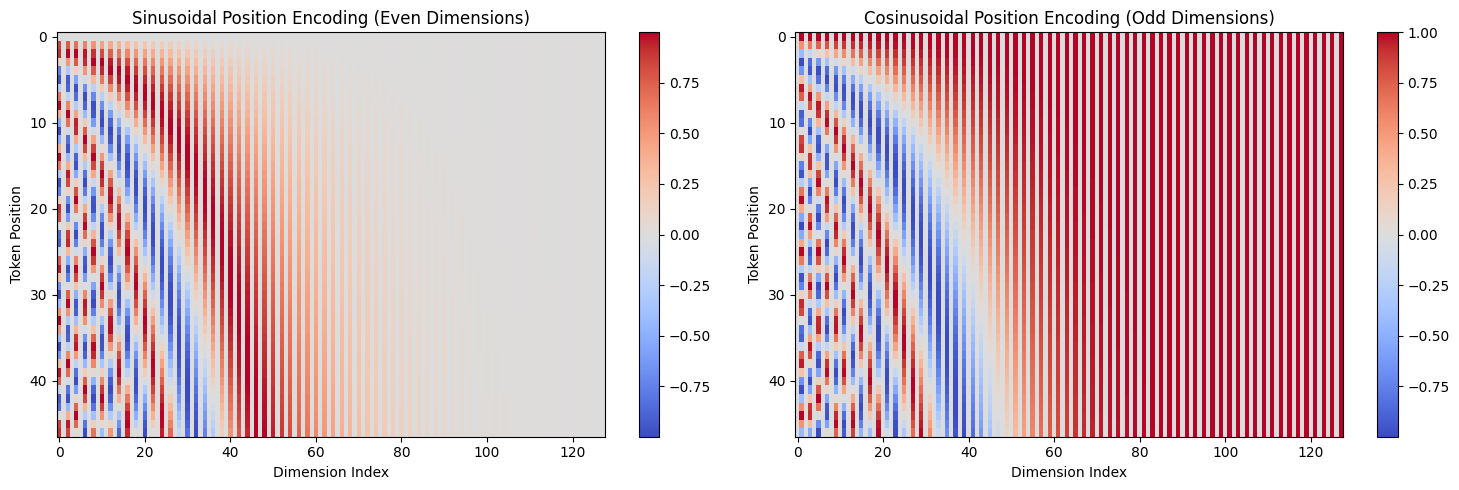

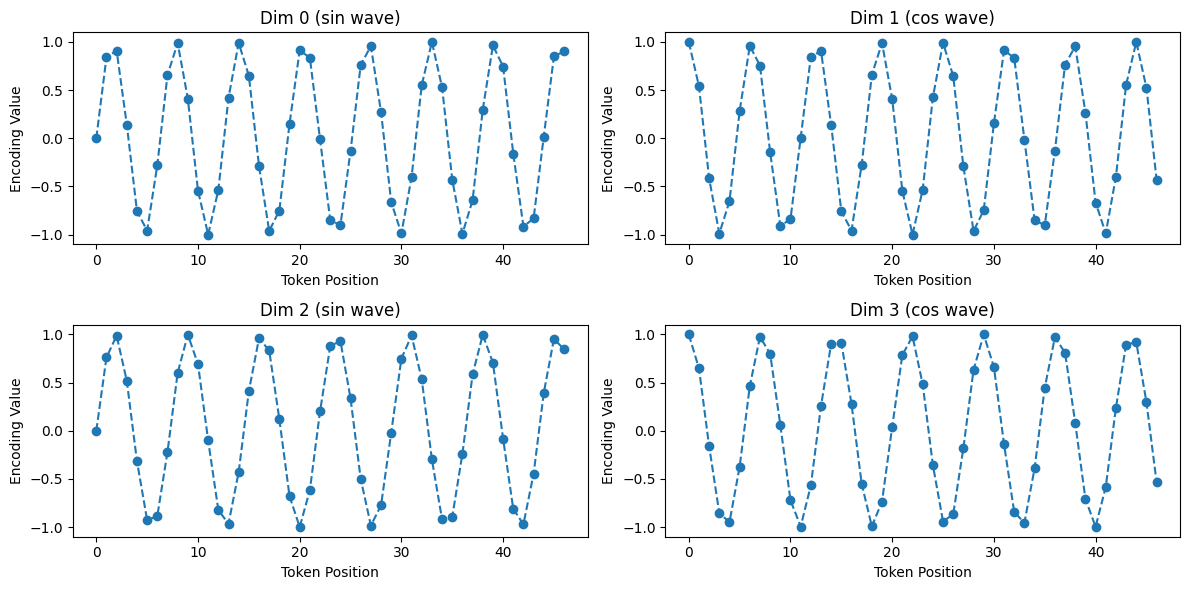

In [10]:
# 修改阶段3：分离显示sin/cos的位置编码
max_len = len(tokens)
d_model = embedding_dim

def positional_encoding(max_len, d_model):
    position = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # 分别创建sin和cos的编码矩阵
    pe_sin = np.zeros((max_len, d_model))
    pe_cos = np.zeros((max_len, d_model))

    pe_sin[:, 0::2] = np.sin(position * div_term)  # 偶数维度用sin
    pe_cos[:, 1::2] = np.cos(position * div_term)  # 奇数维度用cos

    return torch.FloatTensor(pe_sin), torch.FloatTensor(pe_cos)

pe_sin, pe_cos = positional_encoding(max_len, d_model)

# 可视化正弦部分
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(pe_sin.numpy(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Sinusoidal Position Encoding (Even Dimensions)")
plt.xlabel("Dimension Index")
plt.ylabel("Token Position")

# 可视化余弦部分
plt.subplot(1, 2, 2)
plt.imshow(pe_cos.numpy(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Cosinusoidal Position Encoding (Odd Dimensions)")
plt.xlabel("Dimension Index")
plt.ylabel("Token Position")

plt.tight_layout()
plt.show()

# 新增：绘制特定维度的波形图
selected_dims = [0, 1, 2, 3]  # 查看前4个维度的波形
plt.figure(figsize=(12, 6))

for i, dim in enumerate(selected_dims):
    plt.subplot(2, 2, i+1)

    if dim % 2 == 0:  # 偶数维度使用sin
        values = pe_sin[:, dim].numpy()
        func_type = 'sin'
    else:  # 奇数维度使用cos
        values = pe_cos[:, dim].numpy()
        func_type = 'cos'

    plt.plot(values, marker='o', linestyle='--')
    plt.title(f"Dim {dim} ({func_type} wave)")
    plt.xlabel("Token Position")
    plt.ylabel("Encoding Value")
    plt.ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()